 What is Regression?

 Predicting a continuous number from input features

Regression is a supervised learning technique where the goal is to predict a continuous numerical value
(output) from one or more input features. Unlike classification (which predicts a category), regression
predicts a quantity — a house price, tomorrow's temperature, or an employee's expected salary

In [2]:
import numpy as np

hours = np.array([1,2,3,4,5,6,7,8,9,10])
scores = np.array([60,70,80,90,100,110,120,130,140,150])

predicted_score = 10 * 5 + 50

print("Best Fit Line Equation:")
print("score = 10 * hours + 50")

print("\nFor 5 hours → predicted score:", predicted_score)

Best Fit Line Equation:
score = 10 * hours + 50

For 5 hours → predicted score: 100


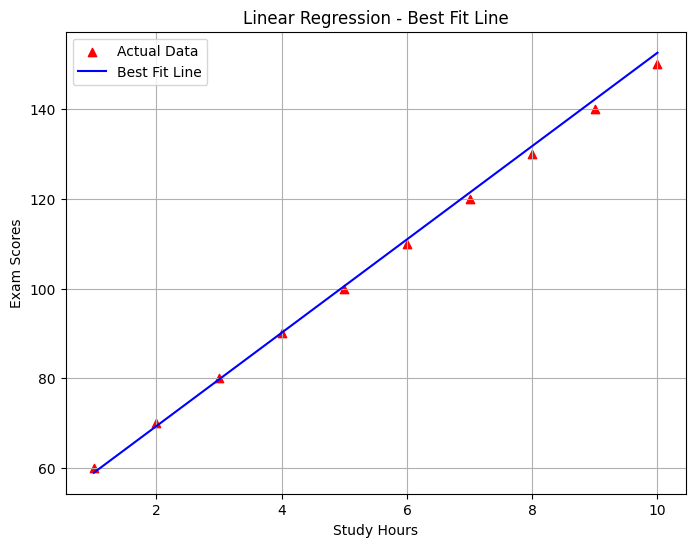

In [3]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.array([1,2,3,4,5,6,7,8,9,10])
scores = np.array([60,70,80,90,100,110,120,130,140,150])

predicted_scores = 10.41 * hours + 48.52

plt.figure(figsize=(8,6))

plt.scatter(hours, scores, label="Actual Data", marker="^", color="red")

plt.plot(hours, predicted_scores, label="Best Fit Line", color="blue")

plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Linear Regression - Best Fit Line")

plt.legend()

plt.grid(True)
plt.show()

# GRADIENT DESCENT

Gradient Descent is the algorithm that actually updates m and c to reduce MSE. Imagine you're
blindfolded on a hilly landscape and want to reach the lowest point (minimum MSE). You feel the slope
under your feet and take a small step downhill. Repeat until you can't go lower.

In [4]:
import numpy as np

x = np.array([1,2,3,4,5], dtype=float)
y = np.array([60,70,80,90,100], dtype=float)

m = 0
c = 0

learning_rate = 0.01
epochs = 1000

n = len(x)

for i in range(epochs):

    y_pred = m * x + c

    error = y - y_pred

    mse = np.mean(error ** 2)

    dm = (-2/n) * np.sum(x * error)
    dc = (-2/n) * np.sum(error)

    m = m - learning_rate * dm
    c = c - learning_rate * dc

    if i % 100 == 0:
        print(f"Epoch {i}")
        print(f"MSE = {mse:.2f}")
        print(f"m = {m:.2f}, c = {c:.2f}")
        print("----------------------")

print("\nFinal Best Fit Line:")
print(f"y = {m:.2f}x + {c:.2f}")

Epoch 0
MSE = 6600.00
m = 5.20, c = 1.60
----------------------
Epoch 100
MSE = 177.90
m = 18.63, c = 18.84
----------------------
Epoch 200
MSE = 90.37
m = 16.15, c = 27.79
----------------------
Epoch 300
MSE = 45.90
m = 14.38, c = 34.17
----------------------
Epoch 400
MSE = 23.32
m = 13.12, c = 38.72
----------------------
Epoch 500
MSE = 11.84
m = 12.23, c = 41.96
----------------------
Epoch 600
MSE = 6.02
m = 11.59, c = 44.27
----------------------
Epoch 700
MSE = 3.06
m = 11.13, c = 45.92
----------------------
Epoch 800
MSE = 1.55
m = 10.81, c = 47.09
----------------------
Epoch 900
MSE = 0.79
m = 10.57, c = 47.93
----------------------

Final Best Fit Line:
y = 10.41x + 48.52


 Building Models with sklearn



■ Golden Rule

80% of data → Training set (model learns from this). 20% of data → Test set (we evaluate on this).

Never let test data
touch the training phase!

In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

experience = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
salary = np.array([35,38,42,48,55,60,65,70,76,82,87,92,96,100,105])

X = experience.reshape(-1, 1)
y = salary

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 12
Testing samples: 3


Fitting and Predicting

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print(f"Slope (coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

y_pred = model.predict(X_test)

for actual, predicted in zip(y_test, y_pred):
    print(
        f"Actual: {actual:>5} | Predicted: {predicted:>7.1f} | Error: {predicted - actual:+.1f}"
    )

Slope (coefficient): 5.22
Intercept: 27.94
Actual:    82 | Predicted:    80.2 | Error: -1.8
Actual:    92 | Predicted:    90.6 | Error: -1.4
Actual:    35 | Predicted:    33.2 | Error: -1.8


 | Metric       | What it tells                | Best for               |
| ------------ | ---------------------------- | ---------------------- |
| **R² Score** | How well model explains data | Model performance      |
| **MAE**      | Average error                | Simple interpretation  |
| **RMSE**     | Penalizes large errors       | Detecting big mistakes |


calculating all three matrics

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_actual = np.array([500, 300, 700, 450, 600])
y_pred = np.array([480, 320, 690, 460, 590])

r2 = r2_score(y_actual, y_pred)

mae = mean_absolute_error(y_actual, y_pred)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print(f"R² Score : {r2:.4f} → model explains {r2*100:.1f}% of variance")
print(f"MAE : {mae:.1f} → avg error ± {mae:.0f} units")
print(f"RMSE : {rmse:.1f} → penalised avg error {rmse:.0f} units")

R² Score : 0.9880 → model explains 98.8% of variance
MAE : 14.0 → avg error ± 14 units
RMSE : 14.8 → penalised avg error 15 units


Multiple Features

– Predicting Salary Real problems have multiple input features. Linear regression handles this naturally: it learns one weight (coefficient) per feature

 What are multiple features

in real life, salary depends on many things:

Experience

Education level

Skills

City

Company

Certifications

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

np.random.seed(42)

n = 100

data = pd.DataFrame({
    'experience': np.random.randint(0, 20, n),
    'education': np.random.randint(12, 20, n),
    'age': np.random.randint(22, 55, n),
})

data['salary'] = (
    data['experience'] * 4500 +
    data['education'] * 2000 +
    data['age'] * 300 +
    np.random.normal(0, 3000, n) +
    10000
)

X = data[['experience', 'education', 'age']]
y = data['salary']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

for feat, coef in zip(X.columns, model.coef_):
    print(f"{feat:12s}: ${coef:,.0f} per unit increase")

print(f"Base salary (intercept): ${model.intercept_:,.0f}")

y_pred = model.predict(X_test)

print(f"\nR² : {r2_score(y_test, y_pred):.3f}")
print(f"MAE : ${mean_absolute_error(y_test, y_pred):,.0f}")

experience  : $4,534 per unit increase
education   : $2,203 per unit increase
age         : $266 per unit increase
Base salary (intercept): $7,694

R² : 0.988
MAE : $2,219
